# Model Development 

In this notebook, we will develop several models that will predict the `price` of the card using other variables/features.

## Dataset 
The dataset is hosted on [IBM Cloud](https://cocl.us/DA101EN_object_storage).  


## Table of Contents 

1. [Import Data and Setup](#import-data)<br>
2. [Linear Regression and Multiple Linear Regression](#linear-multiple)<br>
    2.1 [Linear Regression](#linear-reg)<br>
    2.2 [Multiple Linear Regression](#multi-reg)<br>
3. [Model Evaluation using Visualization](#model-eval)<br>
    3.1 [Regression Plot](#reg-plot)<br>
    3.2 [Residual Plot](#res-plot)<br>
4. [Polynomial Regression and Pipelines](#poly-pipe)<br>
    4.1 [Polynomial Regression](#poly)<br>
    4.2 [Pipeline](#pipe)<br>
5. [Evaluation Metrics](#eval)<br>
6. [Model Selection and Comparison](#model-selection)<br>
7. [Conclusions](#conclusions)<br>


---

## 1. Import Data and Setup <a id="import-data"></a>

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load Data
path ='https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/DA0101EN/automobileEDA.csv'
df = pd.read_csv(path)
df.head()

,symboling,normalized-losses,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,...,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,horsepower-binned,diesel,gas
0,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,0.811148,...,9.0,111.0,5000.0,21,27,13495.0,11.190476,Medium,0,1
1,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,0.811148,...,9.0,111.0,5000.0,21,27,16500.0,11.190476,Medium,0,1
2,1,122,alfa-romero,std,two,hatchback,rwd,front,94.5,0.822681,...,9.0,154.0,5000.0,19,26,16500.0,12.368421,Medium,0,1
3,2,164,audi,std,four,sedan,fwd,front,99.8,0.848630,...,10.0,102.0,5500.0,24,30,13950.0,9.791667,Medium,0,1
4,2,164,audi,std,four,sedan,4wd,front,99.4,0.848630,...,8.0,115.0,5500.0,18,22,17450.0,13.055556,Medium,0,1


## 2. Linear Regression and Multiple Linear Regression <a id="linear-multiple"></a>

### 2.1. Linear Regression <a id="linear-reg"></a>
Simple Linear Regression is a method to help us understand the relationship between two variables.
- The predictor/independent variable $x$
- The response/dependent variable $y$

The result of **Linear Regression** is a **linear function** that predicts the response (**dependent**) variable as a function of the predictor (**independent**) variable.

Where:
- $y$: Dependent Variable
- $x$: Independet Variable (Predictor)

$$
y_{hat} = intercept + slope \cdot x
$$

#### Model 1:
Let's define the **Target Variable** and **Features or Predictors**:
- $y$ = `price`
- $x$ = `highway-mpg`

In [3]:
x = df[['highway-mpg']]
y = df['price']

In [4]:
from sklearn.linear_model import LinearRegression

In [5]:
# Create linear regression object
lm = LinearRegression()
lm

LinearRegression()

In [6]:
# Fit the linear model
lm.fit(x, y)

LinearRegression()

In [7]:
# Predict
yhat = lm.predict(x)
yhat[:5]

array([16236.50464347, 16236.50464347, 17058.23802179, 13771.3045085 ,
       20345.17153508])

In [8]:
# Intercept and Slope
print(f"Intercept: {lm.intercept_}")
print(f"\nSlope: {lm.coef_}")

Intercept: 38423.3058581574

Slope: [-821.73337832]


$$
y_{hat} = intercept + slope \cdot x
$$

Where:
- $y_{hat}$ = Predicted `price`
- $x$ = `highway-mpg`
- $\text{intercept}$ = $38423.3058581574$
- $\text{slope}$ = $-821.73337832$

Then:
$$
\text{Predicted price} = 38423.3058581574 + (-821.73337832 \cdot \text{highway-mpg})
$$

#### Model 2:
- $y$ = `price`
- $x$ = `engine-size`

$$
\text{Predicted price} = intercept + (slope \cdot \text{engine-size})
$$

In [9]:
x = df[['engine-size']]
y = df['price']

lm = LinearRegression()

lm.fit(x, y)

print(f"Intercept: {lm.intercept_}")
print(f"\nSlope: {lm.coef_[0]}")

Intercept: -7963.338906281046

Slope: 166.86001569141598


$$
\text{Predicted price} = intercept + (slope \cdot \text{engine-size})
$$

$$
\text{Predicted price} = -7963.338906281046 + (166.86001569141598 \cdot \text{engine-size})
$$

### 2.2. Multiple Linear Regression <a id="multi-reg"></a>

In real-world applications, we often need to use **multiple variables** to predict a target variable. For this purpose, we use **Multiple Linear Regression**.

Multiple Linear Regression is an extension of Simple Linear Regression. It models the relationship between one **continuous response** (or **dependent**) variable and **two or more predictor** (or **independent**) variables. This method helps us understand how multiple factors together influence the target variable.

Where:
- $y$: Dependent Variable
- $x_1$: Independet Variable 1 (Predictor 1)
- $x_2$: Independet Variable 2 (Predictor 2)
- $x_3$: Independet Variable 3 (Predictor 3)
$$
.
.
.
$$
- $x_n$: Independet Variable n (Predictor n)

Therefore, the equation for a Multiple Linear Regression model is:
$$
y_{hat} = intercept + (slope_1 \cdot X_1) + (slope_2 \cdot X_2) + (slope_3 \cdot X_3) + \dots + (slope_n \cdot X_n)
$$

#### Model 3:
In the previous notebook, we conclude that good **predictors** of `price` could be:
- $x_1$ = `horsepower`
- $x_2$ = `curb-weight`
- $x_3$ = `engine-size`
- $x_4$ = `highway-mpg`

$$
y_{hat} = intercept + (slope_1 \cdot X_1) + (slope_2 \cdot X_2) + (slope_3 \cdot X_3) + (slope_4 \cdot X_4)
$$

$$
\text{Predicted price} = intercept + (slope_1 \cdot \text{horsepower}) + (slope_2 \cdot \text{curb-weigh}) + (slope_3 \cdot \text{engine-size}) + (slope_4 \cdot \text{highway-mpg})\
$$

In [10]:
y = df['price']
x = df[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']]

lm = LinearRegression()

lm.fit(x, y)

print(f"Intercept: {lm.intercept_}\n")
for idx, coef_n in enumerate(lm.coef_):
    print(f"Slope_{idx + 1}: {coef_n}")

Intercept: -15806.624626329194

Slope_1: 53.49574422604928
Slope_2: 4.70770099461392
Slope_3: 81.53026382122768
Slope_4: 36.057488816485886


$$
\text{Predicted price} = intercept + (slope_1 \cdot \text{horsepower}) + (slope_2 \cdot \text{curb-weigh}) + (slope_3 \cdot \text{engine-size}) + (slope_4 \cdot \text{highway-mpg})\
$$

$$
\text{Predicted price} = -15806.624626329194 + (slope_1 \cdot 53.49574422604928) + (slope_2 \cdot 4.70770099461392) + (slope_3 \cdot 81.53026382122768) + (slope_4 \cdot 36.057488816485886)\
$$

## 3. Model Evaluation using Visualization<a id="model-eval"></a>

### 3.1. Regression Plot <a id="reg-plot"></a>
When it comes to **simple linear regression**, a great way to visualize the model fit is by using **regression plots**.

A **regression plot** combines:
- A **scatter plot** that displays the actual data points, and  
- A **fitted linear regression line** that represents the predicted relationship between the variables.


In [11]:
import seaborn as sns
%matplotlib inline 

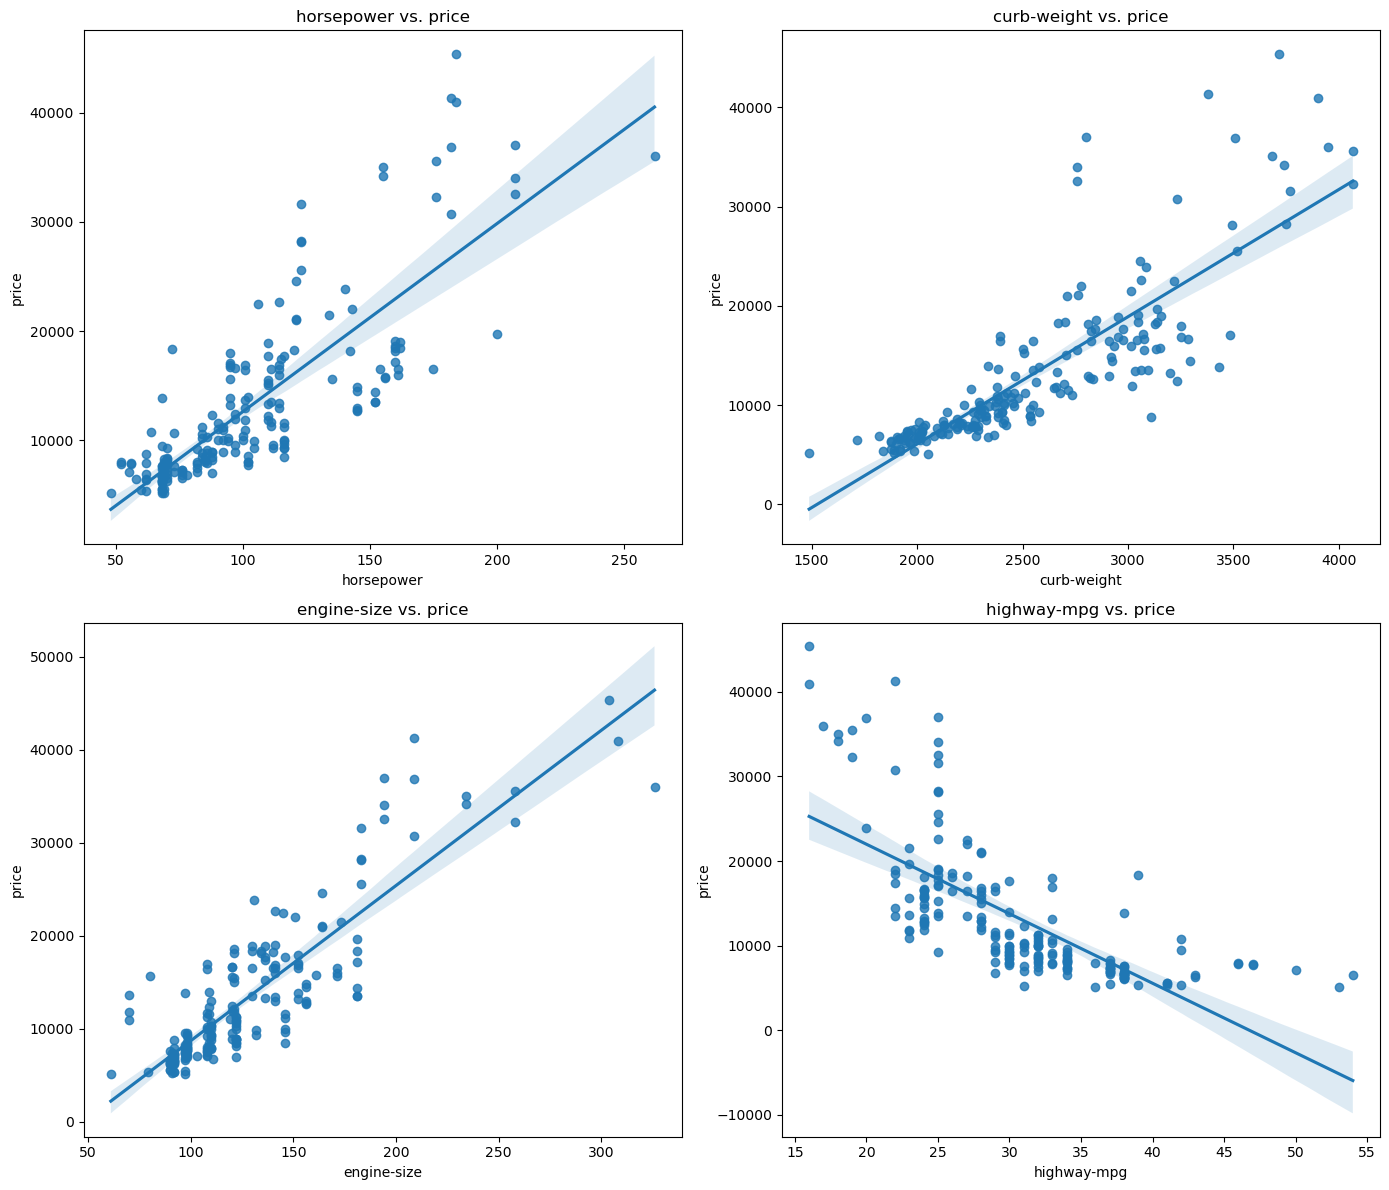

,horsepower,curb-weight,engine-size,highway-mpg,price
horsepower,1.00,0.76,0.82,-0.80,0.81
curb-weight,0.76,1.00,0.85,-0.79,0.83
engine-size,0.82,0.85,1.00,-0.68,0.87
highway-mpg,-0.80,-0.79,-0.68,1.00,-0.70
price,0.81,0.83,0.87,-0.70,1.00


In [12]:
# Set figure size and layout for subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# x1: horsepower vs. price
sns.regplot(data=df, x='horsepower', y='price', ax=axes[0, 0])
axes[0, 0].set_title("horsepower vs. price")
axes[0, 0].set_xlabel("horsepower")
axes[0, 0].set_ylabel("price")

# x2: curb-weight vs. price
sns.regplot(data=df, x='curb-weight', y='price', ax=axes[0, 1])
axes[0, 1].set_title("curb-weight vs. price")
axes[0, 1].set_xlabel("curb-weight")
axes[0, 1].set_ylabel("price")

# x3: engine-size vs. price
sns.regplot(data=df, x='engine-size', y='price', ax=axes[1, 0])
axes[1, 0].set_title("engine-size vs. price")
axes[1, 0].set_xlabel("engine-size")
axes[1, 0].set_ylabel("price")

# x4: highway-mpg vs. price
sns.regplot(data=df, x='highway-mpg', y='price', ax=axes[1, 1])
axes[1, 1].set_title("highway-mpg vs. price")
axes[1, 1].set_xlabel("highway-mpg")
axes[1, 1].set_ylabel("price")

plt.tight_layout()
plt.show()

df[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg', 'price']].corr().round(2)


#### Plot and Correlation Matrix Analysis

##### 1. Horsepower vs. Price (Correlation: 0.81)
- **Plot Observation**: The regression plot shows a **positive trend**, with price increasing as horsepower increases.
- **Interpretation**: The correlation coefficient (**0.81**) confirms a **strong positive relationship**, indicating that higher horsepower is generally associated with higher prices.
- **Fit**: The data points are **moderately clustered** around the regression line, suggesting that **horsepower** is a reliable predictor of price with some variability.

##### 2. Curb Weight vs. Price (Correlation: 0.83)
- **Plot Observation**: The plot shows a **positive trend**, where heavier cars have higher prices.
- **Interpretation**: The strong positive correlation (**0.83**) aligns with the plot, indicating that **curb weight** significantly influences car prices.
- **Fit**: Points are **well-clustered** around the regression line, indicating a **good linear fit**.

##### 3. Engine Size vs. Price (Correlation: 0.87)
- **Plot Observation**: The regression plot shows a **strong positive trend**, with price increasing sharply for larger engines.
- **Interpretation**: The high correlation (**0.87**) supports the visual evidence that **engine size** is a key predictor of price.
- **Fit**: The points are **closely clustered** around the line, indicating a **very strong linear relationship** and a **good fit** for a linear model.

##### 4. Highway MPG vs. Price (Correlation: -0.70)
- **Plot Observation**: The plot shows a **negative trend**, with price decreasing as highway-mpg increases (better fuel efficiency).
- **Interpretation**: The correlation coefficient (**-0.70**) indicates a **strong negative relationship**, where more fuel-efficient cars tend to be less expensive.
- **Fit**: The data points are **moderately scattered** around the line, suggesting variability and indicating that additional features might improve predictions based on **highway-mpg** alone.

#### Overall Observations

##### Strong Predictors:
- **Engine size**, **curb weight**, and **horsepower** show strong positive correlations with price and **good linear fits**.

##### Negative Predictor:
- **Highway-mpg** shows a strong negative correlation with price but has **moderate scatter**, indicating that it may need **additional features** to improve its predictive power.


##### Linear Model Suitability:
- **Variables like engine size and horsepower** are well-suited for a **linear regression model** due to their strong correlations and tight clustering around the regression lines.
- **Multicollinearity** between predictors (e.g., **engine size** and **curb weight**) should be considered when building a model to avoid redundant information.

<div class="alert alert-block" style="background-color:#AEC6CF; color:#000; margin-top: 20px; font-size: 14px;">
    <strong>Note:</strong> <em>Multicollinearity</em> occurs when two or more predictors are highly correlated, leading to unreliable estimates of regression coefficients. This can cause the model’s predictions to become unstable or less interpretable.
</div>

### 3.2. Residual Plot <a id="res-plot"></a>


A **residual plot** helps visualize the variance of the data by showing the **residuals** (the difference between the observed value $y$ and the predicted value $y_{hat}$) on the **y-axis** and the independent variable on the **x-axis**.

- **Residual**:
$$
  \text{Residual} = y - y_{hat}
$$
  Where:
  - $y$ is the observed value (true value)
  - $y_{hat}$ is the predicted value (from the regression line)

#### Interpretation:
- If the residuals are **randomly spread out** around the x-axis, this indicates that the **variance is constant**, making a **linear model appropriate** for the data. This suggests the linear model fits well.
- If there's a pattern or structure in the residuals, it may indicate that a **non-linear model** or additional features are needed.


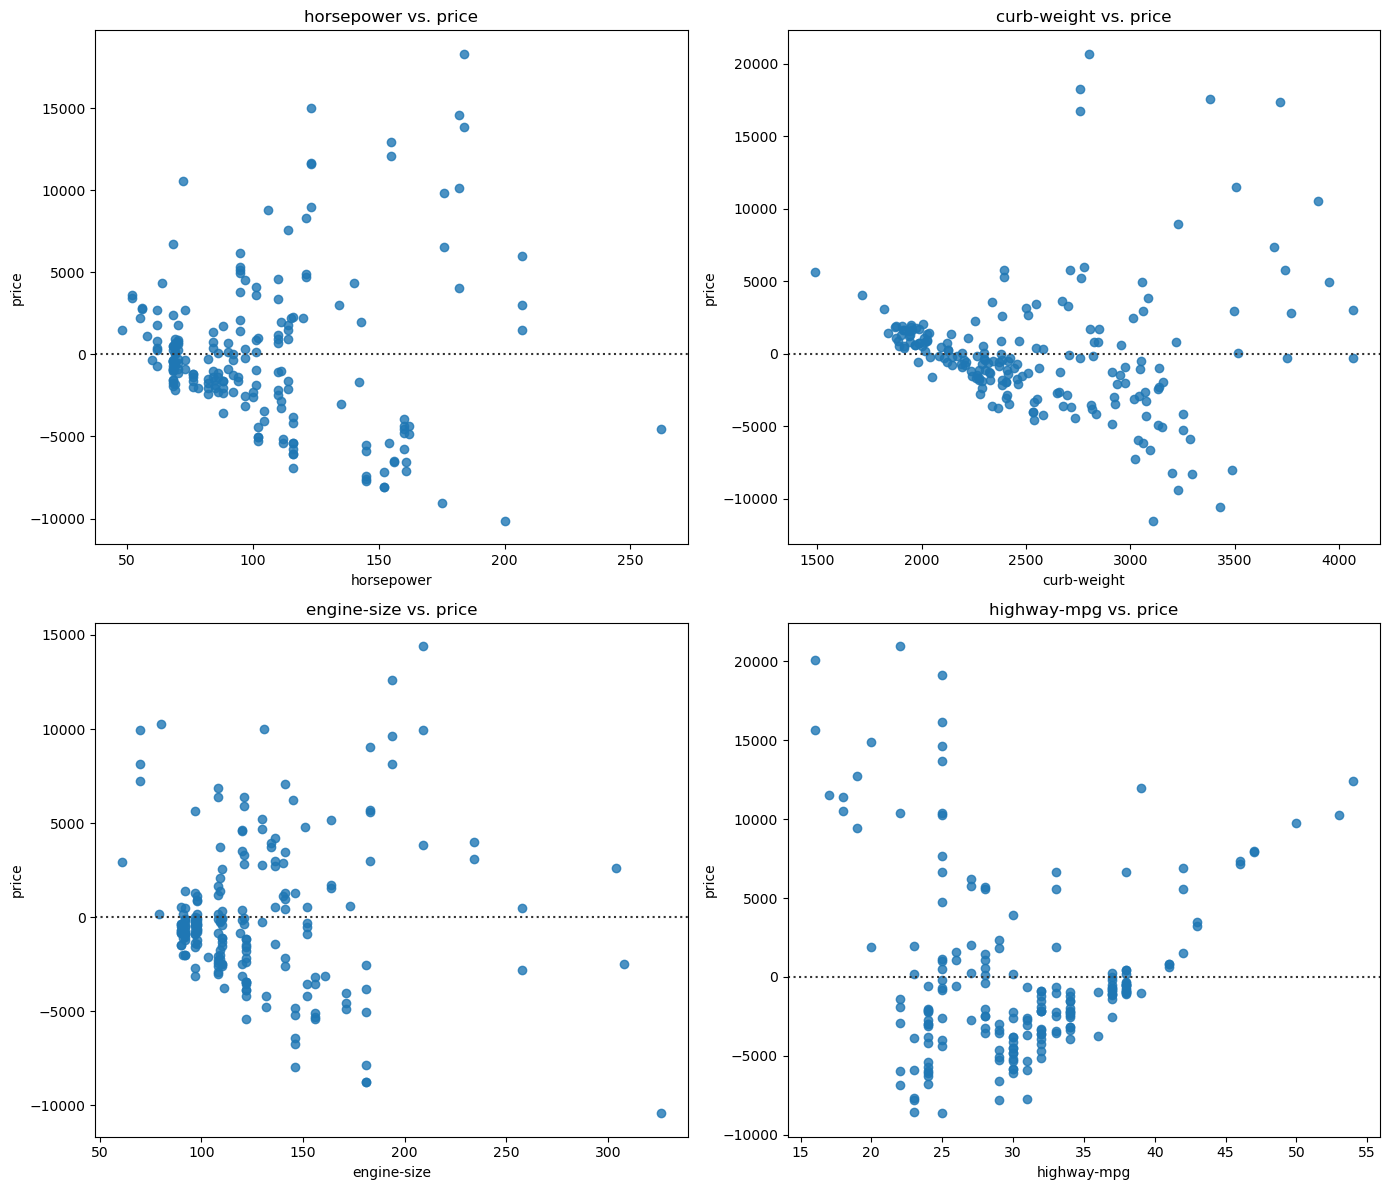

In [13]:
# Set figure size and layout for subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# x1: horsepower vs. price
sns.residplot(data=df, x='horsepower', y='price', ax=axes[0, 0])
axes[0, 0].set_title("horsepower vs. price")
axes[0, 0].set_xlabel("horsepower")
axes[0, 0].set_ylabel("price")

# x2: curb-weight vs. price
sns.residplot(data=df, x='curb-weight', y='price', ax=axes[0, 1])
axes[0, 1].set_title("curb-weight vs. price")
axes[0, 1].set_xlabel("curb-weight")
axes[0, 1].set_ylabel("price")

# x3: engine-size vs. price
sns.residplot(data=df, x='engine-size', y='price', ax=axes[1, 0])
axes[1, 0].set_title("engine-size vs. price")
axes[1, 0].set_xlabel("engine-size")
axes[1, 0].set_ylabel("price")

# x4: highway-mpg vs. price
sns.residplot(data=df, x='highway-mpg', y='price', ax=axes[1, 1])
axes[1, 1].set_title("highway-mpg vs. price")
axes[1, 1].set_xlabel("highway-mpg")
axes[1, 1].set_ylabel("price")

plt.tight_layout()
plt.show()

#### Residual Plot Analysis
Residual plots help us assess whether a linear model is appropriate by showing how the residuals (differences between actual and predicted values) behave.

- Most plots show residuals randomly distributed around the x-axis, indicating that a linear model is generally appropriate for variables like `horsepower`, `engine-size`, and `curb-weight`. For instance in `horsepower` vs. `price`, Residuals are scattered randomly around the x-axis with no clear pattern. This suggests that the linear model fits reasonably well, though there is some variability in predictions.
- On the other hand, the `highway-mpg` plot shows slight clustering, suggesting that some non-linearity or additional predictors might improve predictions.


#### Residual Plot for Multiple Linear Regression
In Multiple Linear Regression, we can evaluate the model's fit by plotting the following:

1. **Residuals vs. Fitted (Predicted) Values**

    **Purpose**: Checks for heteroscedasticity and non-linearity.

    **What to Look For**:
    - Randomly scattered residuals indicate a good fit.
    - Patterns or increasing variance suggest **non-linearity** or **heteroscedasticity**.

<div class="alert alert-block" style="background-color:#AEC6CF; color:#000; margin-top: 20px; font-size: 14px;">
    <strong>Note:</strong> <em>Heteroscedasticity</em> refers to the situation where the variance of the residuals (errors) increases or decreases with the predicted values. This violates the assumption of constant variance in linear regression, and if left unchecked, it can lead to biased predictions and affect the accuracy of statistical tests.
</div>

2. **QQ Plot (Quantile-Quantile Plot)**

    **Purpose**: Assesses whether residuals follow a normal distribution.

    **How It Works**: Compares the quantiles of the residuals with a theoretical normal distribution.

    **What to Look For**:
    - Points should lie on or near the diagonal line if the residuals are normally distributed.
    - Deviations indicate non-normality, which may affect confidence intervals and hypothesis tests.

3. **Histogram of Residuals**

    **Purpose**: Provides a visual assessment of the distribution of residuals.

    **What to Look For**:
    - Residuals should resemble a normal distribution centered at zero.
    - Skewed or heavy-tailed residuals suggest that the model may need adjustments.

In [14]:
# Predict values
yhat = lm.predict(x)

# Calculate residuals
residuals = y - yhat


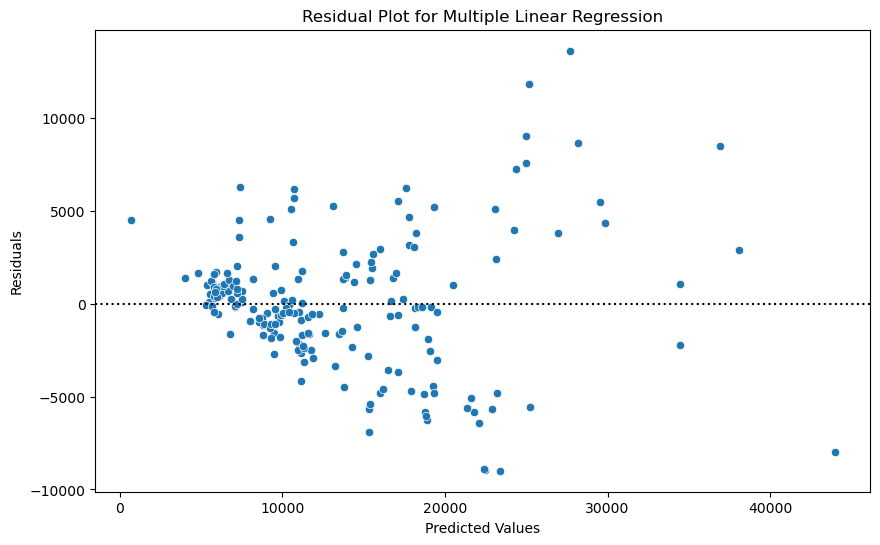

In [15]:
# Residual plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=yhat, y=residuals)
plt.axhline(0, color='black', linestyle='dotted')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot for Multiple Linear Regression')
plt.show()

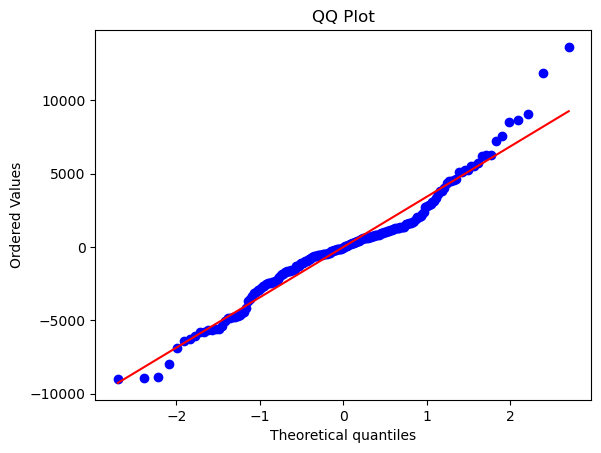

In [16]:
import scipy.stats as stats
import matplotlib.pyplot as plt

# QQ Plot
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('QQ Plot')
plt.show()

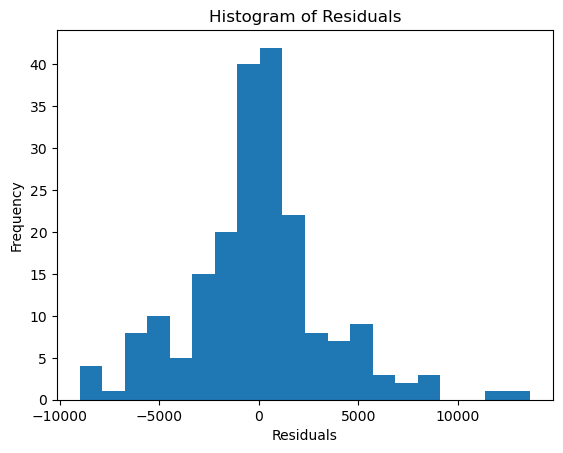

In [17]:
# Histogram
plt.hist(residuals, bins=20)
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Histogram of Residuals')
plt.show()

#### Residual Diagnostics for Multiple Linear Regression

1. **Residuals vs. Fitted (Predicted) Values**
    - Residuals show some scatter with **moderate spread**, especially at higher predicted values.
    - There is some evidence of **heteroscedasticity** as variance increases slightly with larger predicted values.
    - The overall **random scatter** suggests the model captures **linearity** well.

2. **QQ Plot (Quantile-Quantile Plot)**
    - Most points lie close to the diagonal line, but there are **deviations** at the extreme ends.
    - The tail points (both high and low) diverge from the normal line, indicating slightly **heavy tails**.
    - The residuals **approximately follow** a normal distribution, which is generally acceptable.
    - The deviations at the ends suggest that the model might struggle with **extreme values**, but this is not severe enough to raise major concerns.

3. **Histogram of Residuals**
    - The residuals have a roughly **bell-shaped** distribution centered around zero.
    - There is a **slight skew** in the distribution, but it is not extreme.
    - The histogram confirms that residuals are **nearly normally distributed**, supporting the assumption of **normality** in residuals.
    - The slight skew may explain the deviations seen in the QQ plot.


- **Good points**:
    - The residuals are generally **well-behaved**, with no strong evidence of **non-linearity**.
    - **Normality** is approximately satisfied, with minor deviations at the extremes.

- **Areas for improvement**:
    - There is mild **heteroscedasticity** (non-constant variance) visible in the residual vs. predicted plot.
    - Addressing this may involve **transforming variables** (e.g., **logarithmic transformation**) or using **robust regression** techniques.


## 4. Polynomial Regression and Pipelines<a id="poly-pipe"></a>

### 4.1. Polynomial Regression<a id="poly"></a>

Polynomial regression is a special case of the general **linear regression** or **multiple linear regression** models, where **non-linear relationships** are captured by including higher-order terms of the predictor variables.

In this type of regression, we fit the model to a curve by adding **polynomial terms**, such as squared or cubic terms, to the equation.
**Different Orders of Polynomial Regression**
- **Quadratic (2nd order, $X^2$)**
$$
y_{hat} = \text{intercept} + \text{slope}_1 \cdot x + \text{slope}_2 \cdot x^2
$$

- **Cubic (3rd order, $X^3$)**
$$
y_{hat} = \text{intercept} + \text{slope}_1 \cdot x + \text{slope}_2 \cdot x^2 + \text{slope}_3 \cdot x^3
$$

- **Higher Order ($n$ degree)**
$$
y_{hat} = \text{intercept} + \text{slope}_1 X + \text{slope}_2 x^2 + \text{slope}_3 x^3 + \dots + \text{slope}_n x^n
$$


<div class="alert alert-block" style="background-color:#AEC6CF; color:#000; margin-top: 20px; font-size: 14px;">
    <strong>Note:</strong> In the context of <em><strong>polynomial regression</strong> (and <strong>linear regression</strong>)</em>, the coefficients b<sub>1</sub>, b<sub>2</sub>, b<sub>3</sub>, ..., b<sub>n</sub> represent the <strong>slopes</strong> or <strong>weights</strong> for each corresponding term in the equation.
</div>

<div class="alert alert-danger" style="background-color:#f8d7da; color:#721c24; margin-top: 20px; font-size: 14px;">
    <strong>Warning:</strong> <strong>Overfitting</strong> can occur if the degree of the polynomial is too high. It's important to choose the <strong>appropriate degree</strong> of polynomial to balance <strong>model complexity</strong> and <strong>performance</strong>.
</div>

As we observed in the previous section, `highway-mpg` does not perform well in linear model to predict `price`. Let's see if we can find a better fit with polynomial models instead:


In [18]:
def plot_polly(model, x, y, x_label):
    """
    Plots a polynomial regression line along with the original data points.

    Parameters:
    - model: A callable (e.g., numpy.poly1d) representing the polynomial model.
    - x: Array-like, the independent variable (x-values of the data points).
    - y: Array-like, the dependent variable (y-values of the data points).
    - x_label: str, the label for the x-axis.

    Returns:
    - None
    """
    # Generate new x values for plotting the polynomial curve
    x_new = np.linspace(x.min(), x.max(), 100)
    
    # Calculate the corresponding y values using the model
    y_new = model(x_new)

    # Plot the original data points and the polynomial fit
    plt.plot(x, y, '.', label='Data Points')
    plt.plot(x_new, y_new, '-', color='red', label='Polynomial Fit')

    # Set plot title and labels
    plt.title('Polynomial Fit with Matplotlib for Price ~ Length')
    plt.xlabel(x_label)
    plt.ylabel('Price of Cars')
    plt.grid(True, linestyle='--', color='grey', alpha=0.6)
    plt.legend()
    plt.show()


In [19]:
# Input variables
x = df['highway-mpg']
y = df['price']

# Polynomial of the 3rd order (cubic)
coefficients = np.polyfit(x, y, deg=3)

# Create the polynomial function
model = np.poly1d(coefficients)
print("Polynomial Model:\n", model)

Polynomial Model:
         3         2
-1.557 x + 204.8 x - 8965 x + 1.379e+05


$$
y_{hat} = -1.557 x^3 + 204.8 x^2 - 8965 x + 1.379 \times 10^5
$$

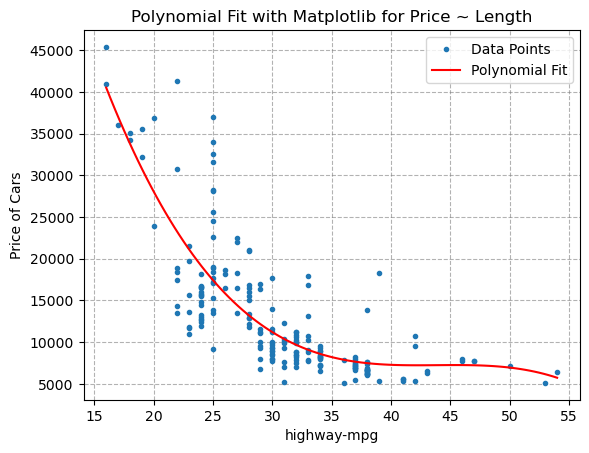

In [20]:
plot_polly(model, x, y, x_label='highway-mpg')

In [21]:
# Evaluate the polynomial at specific x values and print the results
for x_val in range(15, 55, 5):
    y_pred = model(x_val)
    print(f"x = {x_val} | y = {y_pred:.2f}")

x = 15 | y = 44258.16
x = 20 | y = 28063.55
x = 25 | y = 17436.73
x = 30 | y = 11210.24
x = 35 | y = 8216.59
x = 40 | y = 7288.31
x = 45 | y = 7257.91
x = 50 | y = 6957.92


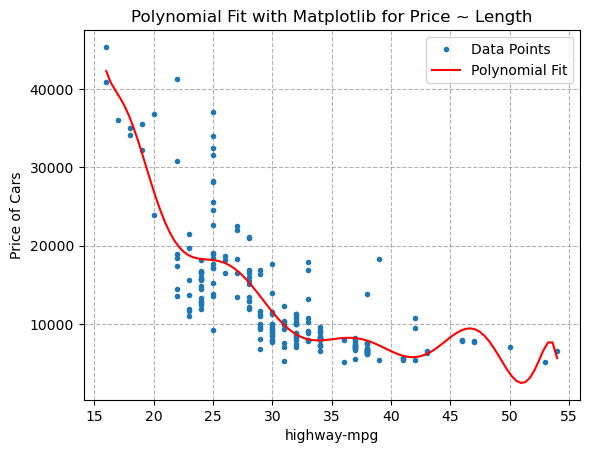

x = 15 | y = 53349.58
x = 20 | y = 27001.25
x = 25 | y = 18154.06
x = 30 | y = 11539.50
x = 35 | y = 8020.06
x = 40 | y = 6509.77
x = 45 | y = 8268.07
x = 50 | y = 3669.96


In [22]:
# Input variables
x = df['highway-mpg']
y = df['price']

# Polynomial of the 3rd order (cubic)
coefficients = np.polyfit(x, y, deg=11)

# Create the polynomial function
model = np.poly1d(coefficients)

# Plot the polynomial fit
plot_polly(model, x, y, x_label='highway-mpg')

# Evaluate the polynomial at specific x values and print the results
for x_val in range(15, 55, 5):
    y_pred = model(x_val)
    print(f"x = {x_val} | y = {y_pred:.2f}")

#### Using `sklearn` for Polynomial Regression
While `np.polyfit()` and `np.poly1d()` are useful for simple polynomial fitting, `sklearn` provides a more structured way to implement polynomial regression, allowing for pipeline creation, evaluation, and model flexibility.

Here’s how you can do the same task using `sklearn`:

**Steps**:
- Transform features with `PolynomialFeatures` (generates polynomial and interaction terms).
- Fit a linear regression model to these transformed features.
- Make predictions and visualize the results.

In [23]:
from sklearn.preprocessing import PolynomialFeatures

In [24]:
# Input variables
x = df[['highway-mpg']] 
y = df['price']

# Step 1: Transform features to 3th degree polynomial
poly = PolynomialFeatures(degree=3)
x_poly = poly.fit_transform(x)

x_poly.shape

(201, 4)

In [25]:
print("[1  x  x^2  x^3]")
print(x_poly[0])

[1  x  x^2  x^3]
[1.0000e+00 2.7000e+01 7.2900e+02 1.9683e+04]


**Explanation**:
- Column 1:
$$\text{intercept} = 1.0000e+00$$
- Column 2: 
$$x = 2.7000e+01$$
- Column 3: 
$$x^2 = 7.2900e+02$$
- Column 4: 
$$x^3 = 1.9683e+04$$

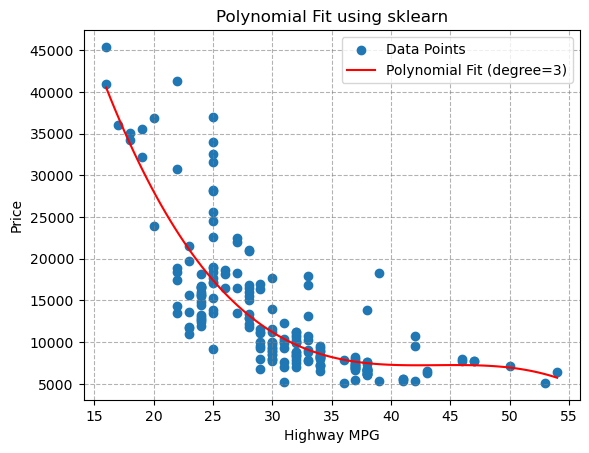

In [26]:
# Step 2: Fit the Linear Regression model on the polynomial features
model = LinearRegression()
model.fit(x_poly, y)

# Step 3: Predict values
x_new = pd.DataFrame(np.linspace(x.min(), x.max(), 100), columns=['highway-mpg'])
x_new_poly = poly.transform(x_new)
y_pred = model.predict(x_new_poly)

# Step 4: Visualize the results
plt.scatter(x, y, label='Data Points')
plt.plot(x_new, y_pred, color='red', label='Polynomial Fit (degree=3)')
plt.xlabel('Highway MPG')
plt.ylabel('Price')
plt.title('Polynomial Fit using sklearn')
plt.legend()
plt.grid(True, linestyle='--', color='grey', alpha=0.6)
plt.show()


### 4.2. Pipelines <a id="pipe"></a>

A **pipeline** is a series of data processing steps chained together, where each step transforms the data and passes the result to the next step. This is especially useful in **machine learning workflows**, where you may need to perform multiple preprocessing steps before fitting a model.

**Why Use Pipelines?**
- **Simplified Workflow**: You define all the steps once and run them as a single process.
- **Consistency**: Prevents **data leakage** by applying the same transformations to training and test data.
- **Maintainability**: Easier to modify or update the process by editing pipeline steps.

**How Does It Work?**
- Define a list of steps, where each step is a tuple (`name`, `transformer`).
    ```python
    pipeline = Pipeline([
        ('scaler', StandardScaler()),               
        ('polynomial', PolynomialFeatures(degree=3)), 
        ('model', LinearRegression()) 
    ])
    ```
- The **Pipeline** applies each step **sequentially**.


In [27]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [28]:
# Input variables
x = df[['highway-mpg']]
y = df['price']

In [29]:
# Define the pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),                 # Step 1: Standardize features
    ('polynomial', PolynomialFeatures()),         # Step 2: Generate polynomial features
    ('model', LinearRegression())                 # Step 3: Fit the linear regression model
])
pipeline

Pipeline(steps=[('scaler', StandardScaler()),
                ('polynomial', PolynomialFeatures()),
                ('model', LinearRegression())])

In [30]:
# Fit the pipeline
pipeline.fit(x, y)

Pipeline(steps=[('scaler', StandardScaler()),
                ('polynomial', PolynomialFeatures()),
                ('model', LinearRegression())])

In [31]:
# Predict new values
x_new = pd.DataFrame(np.linspace(x.min(), x.max(), 100), columns=['highway-mpg'])
y_pred = pipeline.predict(x_new)
y_pred[:5]

array([35431.43138289, 34546.83307859, 33675.59839778, 32817.72734047,
       31973.21990664])

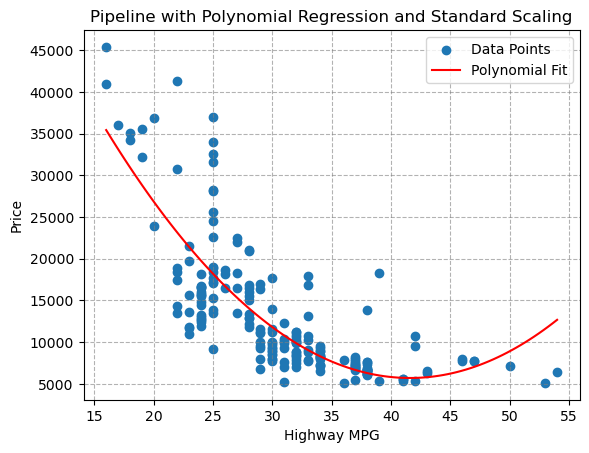

In [32]:
# Visualize the results
plt.scatter(x, y, label='Data Points')
plt.plot(x_new, y_pred, color='red', label='Polynomial Fit')
plt.xlabel('Highway MPG')
plt.ylabel('Price')
plt.title('Pipeline with Polynomial Regression and Standard Scaling')
plt.legend()
plt.grid(True, linestyle='--', color='grey', alpha=0.6)
plt.show()

**Why Generate `x_new` for Visualization?**
To plot a **smooth polynomial curve**, we generate evenly spaced points across the data range:

```python
x_new = pd.DataFrame(np.linspace(x.min(), x.max(), 100), columns=['highway-mpg'])
```
Without this step, the curve might appear jagged or disconnected when using a line plot. While you can skip it and predict directly on the original `x`, using scatter plots would be necessary for better visualization:

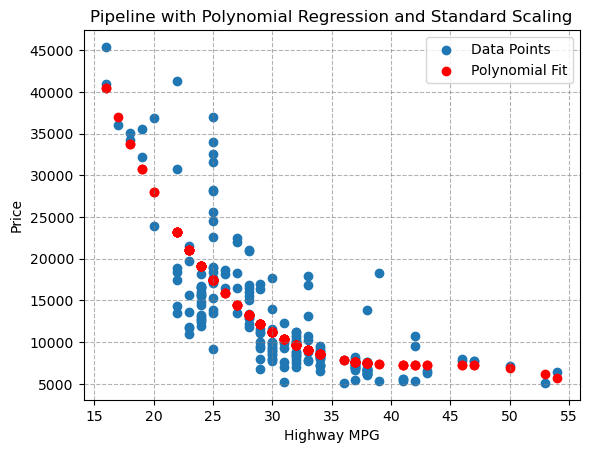

In [33]:
# Input variables
x = df[['highway-mpg']]
y = df['price']

# Define the pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),                 # Step 1: Standardize features
    ('polynomial', PolynomialFeatures(degree=3)),         # Step 2: Generate polynomial features
    ('model', LinearRegression())                 # Step 3: Fit the linear regression model
])

# Fit the pipeline
pipeline.fit(x, y)

# Predict new values
y_pred = pipeline.predict(x)

# Visualize the results
plt.scatter(x, y, label='Data Points')
plt.scatter(x, y_pred, color='red', label='Polynomial Fit')
plt.xlabel('Highway MPG')
plt.ylabel('Price')
plt.title('Pipeline with Polynomial Regression and Standard Scaling')
plt.legend()
plt.grid(True, linestyle='--', color='grey', alpha=0.6)
plt.show()


## 5. Evaluation Metrics <a id="eval"></a>

When evaluating our models, not only do we want to **visualize the results**, but we also need **quantitative measures** to determine how accurate the model is.

Before diving into the metrics, let's define the terms:

- $ y_i $: The **actual values** (or true values) of the target variable.
- $ \hat{y}_i $: The **predicted values** from the model.

Three key metrics often used to evaluate model accuracy are:

1. **Mean Absolute Error (MAE)**: 
   Measures the average magnitude of errors in predictions, without considering their direction. It's the average of absolute differences between predicted and actual values.

   $$ 
   \text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i| 
   $$

2. **Mean Squared Error (MSE)**: 
   Measures the average squared difference between predicted and actual values. It gives higher weight to larger errors, making it sensitive to outliers.

   $$ 
   \text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 
   $$

3. **R-squared (R²)**: 
   Indicates how well the model's predictions match the actual data. A value closer to 1 means better predictive accuracy, while a value closer to 0 indicates a poor fit.

   $$ 
   R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2} 
   $$

These metrics help assess model performance in a straightforward and interpretable way.

We use `sklearn.metrics` to import these evaluation metrics:

In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### **Model 1**: Linear Regression
- $x$ =  ['highway-mpg']

In [35]:
# Input variables and target
x = df[['highway-mpg']]
y = df['price']

# Define the pipeline
lm_pipeline1 = Pipeline([
    ('scaler', StandardScaler()),                
    ('model', LinearRegression())                
])

# Fit the pipeline
lm_pipeline1.fit(x, y)

# Predict new values
y_pred = lm_pipeline1.predict(x)

# Evaluation Metrics
print(f"MAE: {mean_absolute_error(y, y_pred):.4}")
print(f"MSE: {mean_squared_error(y, y_pred):.4f}")
print(f"R2 Score: {r2_score(y, y_pred):.4f}")

MAE: 4.055e+03
MSE: 31635042.9446
R2 Score: 0.4966


##### Model Performance Explanation
- **MAE**: 4.055e+03
    - On average, the predicted prices are off by $\$4,055$  from the actual prices.
    - This is a significant error, suggesting the model might not fully capture all patterns in the data.
- **MSE**: 31635042.9446
    - The MSE is quite large due to the penalty on large errors.
    - The high MSE indicates that some predictions have large deviations from the actual values.
- **R2**: 0.4966
    - An $R^2$ score of **~0.50** means that the model explains only **50%** of the variance in the target variable.
    - This is a mediocre fit, as a strong model typically has an $R^2$ closer to **1**.


### **Model 2**: Linear Regression
- $x$ =  ['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']


In [36]:
# Input variables and target
x = df[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']]
y = df['price']

# Define the pipeline
lm_pipeline2 = Pipeline([
    ('scaler', StandardScaler()),                
    ('model', LinearRegression())                
])

# Fit the pipeline
lm_pipeline2.fit(x, y)

# Predict new values
y_pred = lm_pipeline2.predict(x)

# Evaluation Metrics
print(f"MAE: {mean_absolute_error(y, y_pred):.4f}")
print(f"MSE: {mean_squared_error(y, y_pred):.4f}")
print(f"R2 Score: {r2_score(y, y_pred):.4f}")


MAE: 2450.8014
MSE: 11980366.8707
R2 Score: 0.8094


##### Model Performance Explanation
- **MAE**: 2450.8014
    - On average, the model's predictions are off by $\$2,450$, which is an improvement from the previous error of $\$4,055$.
    - This shows that the model has become more accurate.
- **MSE**: 11980366.8707
    - The **MSE** is also much lower compared to the previous result (**31,635,042**).
    - This reduction in MSE suggests that the model has fewer large errors, improving overall performance.
- **R2**: 0.4966
    - An $R^2$ of **0.81** means that the model explains **81%** of the variance in the target variable.
    - This is a strong indication of a good fit, as models with $R^2$ above **0.80** are generally considered reliable for predictions.


### **Model 3**: Polynomial Regression
- $x$ =  ['highway-mpg']
- `PolynomialFeatures(degree=3)`

In [37]:
# Input variables and target
x = df[['highway-mpg']]
y = df['price']

# Define the pipeline
pm_pipeline = Pipeline([
    ('scaler', StandardScaler()),                 # Step 1: Standardize features
    ('polynomial', PolynomialFeatures(degree=3)),         # Step 2: Generate polynomial features
    ('model', LinearRegression())                 # Step 3: Fit the linear regression model
])

# Fit the pipeline
pm_pipeline.fit(x, y)

# Predict new values
y_pred = pm_pipeline.predict(x)

# Evaluation Metrics
print(f"MAE: {mean_absolute_error(y, y_pred):.4f}")
print(f"MSE: {mean_squared_error(y, y_pred):.4f}")
print(f"R2 Score: {r2_score(y, y_pred):.4f}")


MAE: 2951.9338
MSE: 20474146.4264
R2 Score: 0.6742


##### Model Performance Explanation
- **MAE**: 2951.9338
    - The model's predictions are, on average, off by about $\$2,951$, which is higher than the previous $\$2,450$.
    - This suggests that the model accuracy has declined slightly in terms of absolute errors.
- **MSE**: 20474146.4264
    - The MSE has increased, indicating that some larger errors have worsened.
    - Larger errors contribute heavily to MSE, so this suggests that the model may not fully handle certain data points correctly.
- **R2**: 0.6742
    - The model explains 67% of the variance in the target variable.
    - This is lower than the previous score of **0.81**, suggesting that the model is not capturing the data as well.
    - While an $R^2$ score of **0.67** is still moderately good, it's less reliable for precise predictions.

## 6. Model Selection and Comparison <a id="model-selection"></a>
Now that we have visualized different models and evaluated them using **R² Score**, **MAE**, and **MSE**, we can determine which model provides the best fit for predicting the target variable (`price`).

In this section, we summarize the results and rerun the most promising model to validate and visualize the final output.

### **Model Comparison Results**

Below is a summary of the evaluation metrics for the three regression models:

| **Model**                           | **Features**                                              | **MAE**    | **MSE**          | **R² Score** |
|--------------------------------------|-----------------------------------------------------------|-------------|-------------------|---------------|
| Linear Regression (1 feature)        | `['highway-mpg']`                                         | 2,450.80    | 11,980,366.87     | 0.8094        |
| Linear Regression (4 features)       | `['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']` | 2,951.93    | 20,474,146.43     | 0.6742        |
| Polynomial Regression (degree=3)     | `['highway-mpg']`                                         | 2,951.93    | 20,474,146.43     | 0.6742        |

#### **Interpretation**
1. **Linear Regression (1 feature)**:
   - Achieved the best performance with the lowest **MAE**, **MSE**, and highest **R² Score** (0.8094), indicating a good fit.

2. **Linear Regression (4 features)**:
   - Including more features increased both the **MAE** and **MSE**, reducing the **R² Score** to 0.6742.
   - This could indicate multicollinearity or a lack of additional useful information from the extra features.

3. **Polynomial Regression (degree=3)**:
   - Despite the use of polynomial features, the performance did not improve compared to the simple linear model with 1 feature, suggesting the model might be overfitting or capturing noise instead of useful patterns.

#### **Model Validation**
Based on the evaluation metrics and previous plots, **Model 2 (Linear Regression with 4 features)** provides the best balance of accuracy and generalization for predicting car prices. We will now re-run this model, generate the predictions, and plot the results to validate its performance.


MAE: 2450.8014
MSE: 11980366.8707
R2 Score: 0.8094


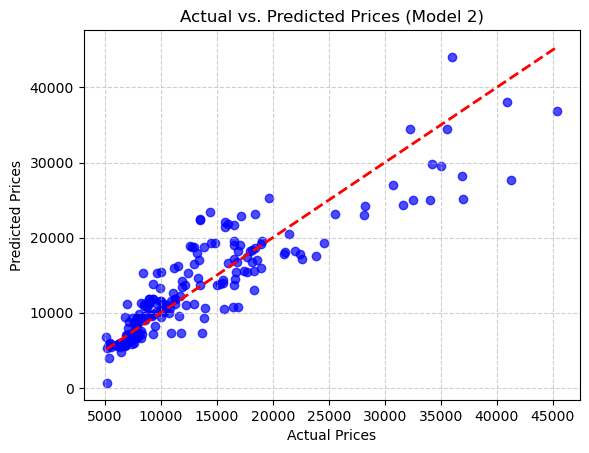

In [38]:
# Input variables and target
x = df[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']]
y = df['price']

# Define the pipeline
lm_pipeline2 = Pipeline([
    ('scaler', StandardScaler()),                
    ('model', LinearRegression())                
])

# Fit the pipeline
lm_pipeline2.fit(x, y)

# Predict new values
y_pred = lm_pipeline2.predict(x)

# Evaluation Metrics
print(f"MAE: {mean_absolute_error(y, y_pred):.4f}")
print(f"MSE: {mean_squared_error(y, y_pred):.4f}")
print(f"R2 Score: {r2_score(y, y_pred):.4f}")

# Plot the predicted vs actual values
plt.scatter(y, y_pred, alpha=0.7, color='blue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--', linewidth=2)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs. Predicted Prices (Model 2)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### **Model Visualization and Analysis**

#### **1. Actual vs. Predicted Prices Plot**
- **Diagonal Red Line**: Represents perfect predictions where the actual values equal the predicted values.
- **Scatter Points**:  
   - Most points cluster near the red line, indicating that the model predicts many data points accurately.
   - There are deviations, especially at higher price ranges, suggesting underfitting or missing features.

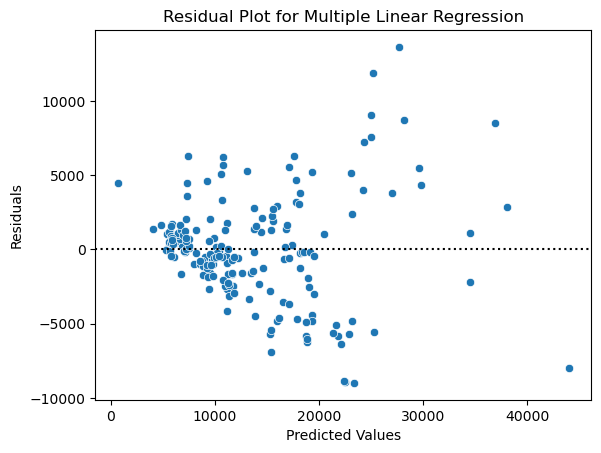

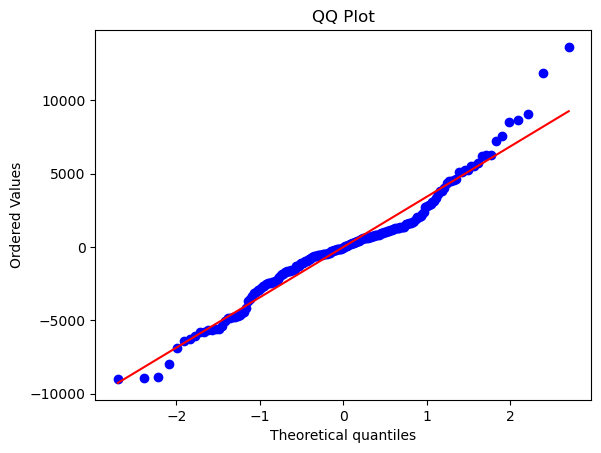

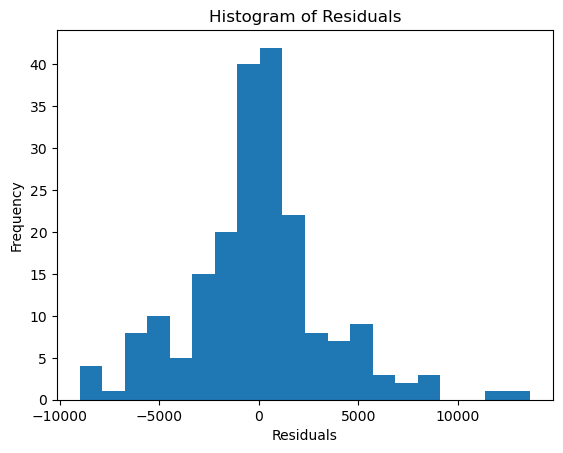

In [39]:
# Calculate residuals
residuals = y - y_pred

# Residual plot
sns.scatterplot(x=yhat, y=residuals)
plt.axhline(0, color='black', linestyle='dotted')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot for Multiple Linear Regression')
plt.show()

# QQ Plot
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('QQ Plot')
plt.show()

# Histogram
plt.hist(residuals, bins=20)
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Histogram of Residuals')
plt.show()

### **2. Residual Analysis**

We analyzed the residuals (errors) to evaluate model assumptions and fit quality.

1. **Residual Plot**:
   - **Description**: Shows residuals vs. predicted values.
   - **Interpretation**:
     - Residuals are randomly scattered around the horizontal line, indicating no clear pattern and supporting the assumption of constant variance (homoscedasticity).
     - Deviations at higher prices suggest potential underfitting.

2. **QQ Plot**:
   - **Description**: Compares the residuals to a normal distribution.
   - **Interpretation**:
     - Points lie near the diagonal line, indicating that the residuals are approximately normal.
     - Some tail deviations suggest slight skewness.

3. **Histogram of Residuals**:
   - **Description**: Shows the frequency distribution of residuals.
   - **Interpretation**:
     - The histogram resembles a bell curve, supporting the normality assumption.
     - A slight right skew is observed, confirming what was seen in the QQ plot.



## 7. Conclusions <a id="conclusions"></a>

1. **Model Selection**:
   - The single-feature linear regression model with `highway-mpg` provided the best overall performance, as indicated by the evaluation metrics and residual analysis.

2. **Model Improvement**:
   - The linear regression model with multiple features did not significantly outperform the simpler model, suggesting the need for further feature engineering or exploration of non-linear models.

3. **Diagnostic Findings**:
   - Residuals are approximately normal and show no major violations of model assumptions, but deviations at higher price points suggest the model may not fully capture all relationships in the data.
